
 DATA LOADING AND INITIAL ANALYSIS 

Dataset Dimensions:
Total Records: 3,553
Total Features: 27

 DATA TYPES ANALYSIS 

Summary of Data Types:
int32     15
object    12
Name: count, dtype: int64

Detailed Data Types for Each Column:
url                      : object
price_in_rp              : int32
title                    : object
address                  : object
district                 : object
city                     : object
lat                      : int32
long                     : int32
facilities               : object
property_type            : object
ads_id                   : object
bedrooms                 : int32
bathrooms                : int32
land_size_m2             : int32
building_size_m2         : int32
carports                 : int32
certificate              : object
electricity              : int32
maid_bedrooms            : int32
maid_bathrooms           : int32
floors                   : int32
building_age             : int32
year_built               : int

<Figure size 1200x600 with 0 Axes>

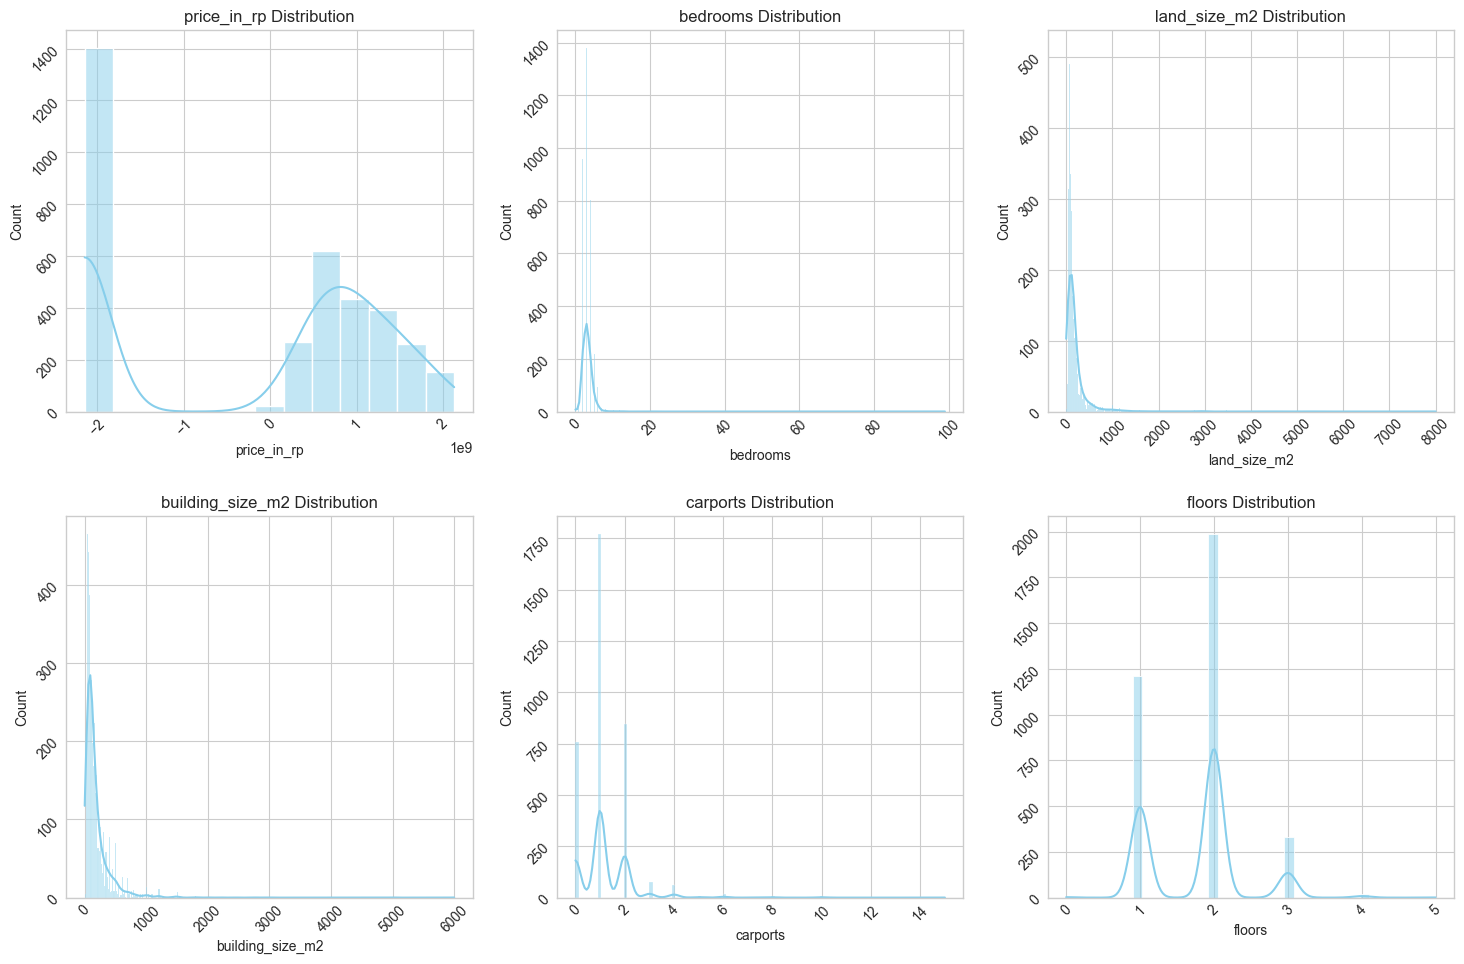


 OUTLIER ANALYSIS 

Outlier Summary:
Error during analysis: index 0 is out of bounds for axis 0 with size 0


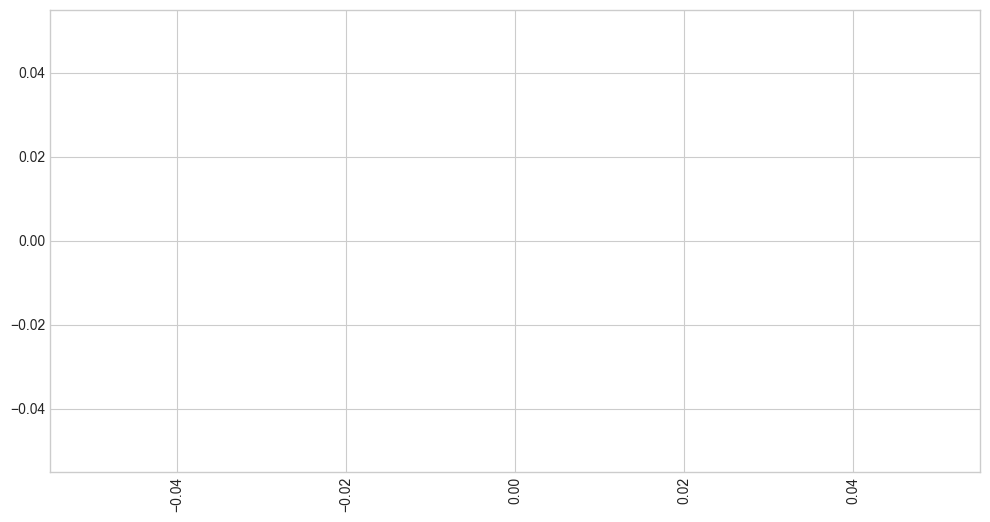

In [33]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Suppress all warnings
warnings.filterwarnings('ignore')

# Set style for better figure layout
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

def format_currency(value):
    """Format numbers as Indonesian Rupiah currency"""
    return f"Rp {value:,.2f}"

def print_section_header(title):
    """Print formatted section header"""
    print("\n" + "="*50)
    print(f" {title} ")
    print("="*50 + "\n")

def make_plot(func):
    """Decorator to handle plot layout"""
    def wrapper(*args, **kwargs):
        plt.figure()
        func(*args, **kwargs)
        plt.tight_layout(pad=2.0, h_pad=2.0, w_pad=2.0)
        plt.show()
        plt.close()
    return wrapper

def analyze_balance(data, column, threshold=0.2):
    """
    Analyze balance/imbalance in a column
    threshold: maximum ratio difference to consider as balanced
    """
    value_counts = data[column].value_counts()
    proportions = value_counts / len(data)

    max_prop = proportions.max()
    min_prop = proportions.min()
    imbalance_ratio = max_prop / min_prop if min_prop > 0 else float('inf')

    print(f"\nImbalance Metrics:")
    print(f"  - Imbalance Ratio: {imbalance_ratio:.2f}")
    print(f"  - Maximum Proportion: {max_prop:.4f}")
    print(f"  - Minimum Proportion: {min_prop:.4f}")

    status = "Imbalanced" if imbalance_ratio > (1 + threshold) else "Balanced"
    print(f"  - Status: {status}")

    return {
        'column': column,
        'status': status,
        'imbalance_ratio': imbalance_ratio,
        'distribution': value_counts
    }

@make_plot
def plot_missing_values(missing_values_summary):
    missing_values_summary['Percentage'].plot(kind='bar', color='skyblue')
    plt.title('Percentage of Missing Values per Column', fontsize=12)
    plt.xlabel('Columns', fontsize=10)
    plt.ylabel('Percentage of Missing Values', fontsize=10)
    plt.xticks(rotation=45, ha='right')

@make_plot
def plot_distribution(data, columns, n_cols=3):
    n_rows = (len(columns) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(data[col].dropna(), kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'{col} Distribution')
        axes[i].tick_params(labelrotation=45)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

@make_plot
def plot_outliers(outlier_counts):
    outlier_counts.sort_values(ascending=False).plot(kind='bar', color='salmon')
    plt.title('Number of Outliers per Numerical Feature', fontsize=12)
    plt.xlabel('Features', fontsize=10)
    plt.ylabel('Number of Outliers', fontsize=10)
    plt.xticks(rotation=45, ha='right')

@make_plot
def plot_feature_importance(feature_importance):
    sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
    plt.title('Feature Importance from Random Forest', fontsize=12)
    plt.xlabel('Importance Score', fontsize=10)
    plt.ylabel('Feature', fontsize=10)

@make_plot
def plot_balance_distribution(data, column):
    sns.countplot(data=data, x=column)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

@make_plot
def plot_balance_dashboard(imbalance_df, balance_results):
    fig = plt.figure(figsize=(15, 10))
    gs = plt.GridSpec(2, 2, figure=fig)

    ax2 = fig.add_subplot(gs[1, 0])
    balance_status = pd.Series([r['status'] for r in balance_results.values()]).value_counts()
    ax2.pie(balance_status, labels=balance_status.index, autopct='%1.1f%%')
    ax2.set_title('Proportion of Balanced vs Imbalanced Features')


def modify_data_types(data):
    # Identify float columns and convert to integer
    float_columns = data.select_dtypes(include=['float64']).columns
    for col in float_columns:
        data[col] = data[col].fillna(0).astype(int)

    # Identify object columns and convert to string
    object_columns = data.select_dtypes(include=['object']).columns
    for col in object_columns:
        # Special handling for electricity column
        if col == 'electricity':
            # Remove ' mah' and 'lainnya mah' from electricity column
            data[col] = data[col].str.replace(' mah', '').str.replace('lainnya mah', '')
            # Convert to integer, filling NaN with 0
            data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0).astype(int)
        else:
            # Convert other object columns to string
            data[col] = data[col].astype(str)

    return data

def main():
    # 1. Load and Initial Analysis
    print_section_header("DATA LOADING AND INITIAL ANALYSIS")
    file_path = 'mentah.csv'
    data = pd.read_csv(file_path)

    # Modify data types
    data = modify_data_types(data)

    print("Dataset Dimensions:")
    print(f"Total Records: {data.shape[0]:,}")
    print(f"Total Features: {data.shape[1]:,}")

    # 2. Data Types Analysis
    print_section_header("DATA TYPES ANALYSIS")
    dtype_summary = data.dtypes.value_counts()
    print("Summary of Data Types:")
    print(dtype_summary)
    print("\nDetailed Data Types for Each Column:")
    for column, dtype in data.dtypes.items():
        print(f"{column:<25}: {dtype}")

    # 3. Missing Values Analysis
    print_section_header("MISSING VALUES ANALYSIS")
    missing_values = data.isnull().sum()
    missing_values_percentage = (missing_values / len(data)) * 100
    missing_values_summary = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage': missing_values_percentage.round(2)
    }).sort_values(by='Percentage', ascending=False)

    # Perbaikan: Gunakan numeric_cols yang sudah diupdate
    numeric_cols = data.select_dtypes(include=['int64']).columns

    # 4. Descriptive Statistics
    print_section_header("DESCRIPTIVE STATISTICS")

    for col in numeric_cols:
        stats = data[col].describe()
        print(f"\nStatistics for {col}:")
        if 'price' in col.lower():
            print(f"  Minimum  : {format_currency(stats['min'])}")
            print(f"  Maximum  : {format_currency(stats['max'])}")
            print(f"  Mean     : {format_currency(stats['mean'])}")
            print(f"  Median   : {format_currency(stats['50%'])}")
        else:
            print(f"  Minimum  : {stats['min']:,.0f}")
            print(f"  Maximum  : {stats['max']:,.0f}")
            print(f"  Mean     : {stats['mean']:,.2f}")
            print(f"  Median   : {stats['50%']:,.0f}")
        print(f"  Std Dev  : {stats['std']:,.2f}")

    # Perbaikan: Gunakan kolom numerik yang sudah diupdate
    plot_distribution(data, ['price_in_rp', 'bedrooms', 'land_size_m2',
                           'building_size_m2', 'carports', 'floors'])

    # 5. Outlier Analysis
    print_section_header("OUTLIER ANALYSIS")
    z_scores = zscore(data[numeric_cols].dropna())
    z_scores_df = pd.DataFrame(z_scores, columns=numeric_cols)
    outliers = (z_scores_df > 3) | (z_scores_df < -3)
    outlier_counts = outliers.sum()

    print("Outlier Summary:")
    for feature, count in outlier_counts.items():
        percentage = (count / len(data)) * 100
        print(f"\n{feature}:")
        print(f"  - Number of outliers: {count:,}")
        print(f"  - Percentage: {percentage:.2f}%")

    plot_outliers(outlier_counts)

    # 6. Feature Importance Analysis
    print_section_header("FEATURE IMPORTANCE ANALYSIS")
    data_clean = data.dropna(subset=['price_in_rp'])
    X_clean = data_clean[numeric_cols]
    y_clean = data_clean['price_in_rp']

    # Pastikan menggunakan kolom numerik yang sudah diupdate
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X_clean)

    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_clean,
                                                        test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    feature_importance = pd.DataFrame({
        'Feature': X_clean.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("Feature Importance Ranking:")
    for idx, row in feature_importance.iterrows():
        print(f"\n{row['Feature']}:")
        print(f"  - Importance Score: {row['Importance']:.4f}")
        print(f"  - Relative Importance: {row['Importance']/feature_importance['Importance'].sum()*100:.2f}%")

    plot_feature_importance(feature_importance)

    # 7. Dataset Balance Analysis
    print_section_header("DATASET BALANCE ANALYSIS")
    categorical_cols = data.select_dtypes(include=['object']).columns
    balance_results = {}

    print("\nCategorical Features Balance Analysis:")
    for col in categorical_cols:
        balance_results[col] = analyze_balance(data, col)
        plot_balance_distribution(data, col)

    print("\nNumerical Features Balance Analysis (after binning):")
    for col in numeric_cols:
        data[f'{col}_binned'] = pd.qcut(data[col], q=4, duplicates='drop')
        balance_results[f'{col}_binned'] = analyze_balance(data, f'{col}_binned')
        plot_balance_distribution(data, f'{col}_binned')
        data = data.drop(columns=[f'{col}_binned'])

    imbalance_scores = [result['imbalance_ratio'] for result in balance_results.values()]
    overall_imbalance = np.mean(imbalance_scores)

    print("\nOverall Dataset Balance Summary:")
    print(f"Average Imbalance Ratio: {overall_imbalance:.2f}")

    sorted_imbalance = sorted(balance_results.items(),
                            key=lambda x: x[1]['imbalance_ratio'],
                            reverse=True)

    print("\nMost Imbalanced Features:")
    for feature, result in sorted_imbalance[:3]:
        print(f"\n{feature}:")
        print(f"  - Imbalance Ratio: {result['imbalance_ratio']:.2f}")
        print(f"  - Status: {result['status']}")

    imbalance_df = pd.DataFrame([
        {'Feature': k, 'Imbalance_Ratio': v['imbalance_ratio']}
        for k, v in balance_results.items()
    ])

    plot_balance_dashboard(imbalance_df, balance_results)


    # Create analysis summary dictionary
    analysis_summary = {
        'dataset_info': {
            'total_records': data.shape[0],
            'total_features': data.shape[1],
            'timestamp': pd.Timestamp.now()
        },
        'missing_values': missing_values_summary.to_dict(),
        'feature_importance': feature_importance.to_dict(),
        'balance_analysis': balance_results,
        'descriptive_stats': {
            col: data[col].describe().to_dict()
            for col in numeric_cols
        }
    }

    print("\nAnalysis completed successfully!")


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print(f"Error during analysis: {str(e)}")

In [34]:
import pandas as pd

# 1. Membaca Dataset
dataset_1 = pd.read_csv('mentah.csv')

# 2. Drop kolom yang tidak relevan
columns_to_keep = [
    'price_in_rp', 'city', 'bedrooms', 'bathrooms',
    'land_size_m2', 'building_size_m2', 'carports',
    'electricity', 'floors',
    'year_built', 'garages'
]
dataset_1 = dataset_1[columns_to_keep]

# 3. Hapus string "mah" dan "lainnya mah" pada kolom Electricity
dataset_1['electricity'] = dataset_1['electricity'].replace({' mah': '', 'lainnya mah': ''}, regex=True)

# 4. Perbaiki jenis tipe data tiap kolom
# Tambahkan penanganan untuk kolom yang mungkin berisi string
def clean_numeric_column(series):
    # Hapus karakter non-numerik kecuali titik desimal
    return pd.to_numeric(series.astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Daftar kolom yang akan dikonversi ke numerik
numeric_columns = [
    'price_in_rp', 'bedrooms', 'bathrooms', 'land_size_m2',
    'building_size_m2', 'carports', 'electricity', 'floors',
    'year_built', 'garages'
]

# Terapkan pembersihan numerik
for column in numeric_columns:
    dataset_1[column] = clean_numeric_column(dataset_1[column])

# 5. Tangani nilai null/kosong
for column in ['bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2',
               'carports', 'electricity', 'floors', 'garages']:
    dataset_1[column].fillna(dataset_1[column].mean(), inplace=True)

# 6. Menghitung rata-rata dari year_built, mengabaikan nilai 0 dan NaN
year_built_mean = dataset_1['year_built'][dataset_1['year_built'] > 0].mean()

# 7. Mengisi NaN pada year_built dengan rata-rata yang dihitung
dataset_1['year_built'].fillna(year_built_mean, inplace=True)

# 8. Pastikan tidak ada NaN sebelum konversi
for column in numeric_columns:
    dataset_1[column].fillna(0, inplace=True)  # Mengisi NaN dengan 0
    dataset_1[column] = dataset_1[column].astype(int)  # Konversi ke integer

# 9. One Hot Encoding untuk kolom city dan certificate tanpa prefix
city_dummies = pd.get_dummies(dataset_1['city'], drop_first=False)

# 10. Gabungkan hasil one hot encoding dengan DataFrame asli
dataset_1 = pd.concat([dataset_1, city_dummies], axis=1)

# 11. Hapus kolom asli city dan certificate
dataset_1.drop(columns=['city'], inplace=True)

# 12. Pastikan tipe data kolom hasil one hot encoding adalah integer
for column in dataset_1.columns:
    if column in column in city_dummies.columns:
        dataset_1[column] = dataset_1[column].astype(int)

# 13. Simpan hasil ke dalam file CSV
dataset_1.to_csv('masih ada outlier_belum normal.csv', index=False)

print("Preprocessing selesai. Dataset telah disimpan sebagai '.csv'.")

Preprocessing selesai. Dataset telah disimpan sebagai '.csv'.


In [35]:
import pandas as pd
import numpy as np

# Memuat dataset
file_path = 'masih ada outlier_belum normal.csv'  # Ganti dengan path file Anda
data = pd.read_csv(file_path)

# Menghitung z-score untuk kolom numerik
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
z_scores = np.abs((data[numeric_columns] - data[numeric_columns].mean()) / data[numeric_columns].std())

# Menetapkan threshold untuk mendeteksi outlier
threshold = 3
outlier_indices = np.where((z_scores > threshold).any(axis=1))[0]

# Memfilter outlier yang terdeteksi
outliers = data.iloc[outlier_indices]

# Menyaring outlier yang tidak boleh dihapus
valid_outliers = outliers[(outliers[numeric_columns] > 0).any(axis=1) & (data.loc[outlier_indices, numeric_columns].count(axis=1) > 0)]

# Mengurangi maksimal 500 baris outlier
rows_to_remove = min(len(valid_outliers), 500)

# Mengambil indeks dari outlier yang akan dihapus
final_outlier_indices = valid_outliers.index[:rows_to_remove]

# Menghapus outlier dari dataset
cleaned_data = data.drop(index=final_outlier_indices)

# Menyimpan dataset yang telah dibersihkan
cleaned_file_path = 'cleaned_dataset.csv'  # Path untuk menyimpan dataset yang sudah dibersihkan
cleaned_data.to_csv(cleaned_file_path, index=False)

print(f'Dataset yang telah dibersihkan disimpan di: {cleaned_file_path}')

Dataset yang telah dibersihkan disimpan di: cleaned_dataset.csv


In [38]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

# Baca dataset
df = pd.read_csv('cleaned_dataset.csv')

# Simpan tipe data asli
original_dtypes = df.dtypes.to_dict()

# Daftar fitur one-hot encoding
one_hot_features = [
    ' Bogor', ' Depok', ' Jakarta Barat',
    ' Jakarta Pusat', ' Jakarta Selatan',
    ' Jakarta Timur', ' Jakarta Utara', ' Tangerang', " Bekasi"
]

#metode balancing apa yang digunakan di bawah ini
# Fungsi untuk balancing fitur
def balance_one_hot_features(dataframe, features, target_count=250):
    # Buat salinan dataframe
    balanced_df = dataframe.copy()

    for feature in features:
        # Pisahkan data dengan label 1 dan 0
        data_with_label = balanced_df[balanced_df[feature] == 1]
        data_without_label = balanced_df[balanced_df[feature] == 0]

        # Hitung jumlah saat ini
        current_count = len(data_with_label)

        if current_count > target_count:
            # Undersampling: kurangi data dengan label 1
            data_with_label_resampled = resample(
                data_with_label,
                replace=False,
                n_samples=target_count,
                random_state=42
            )

            # Gabungkan kembali
            balanced_df = pd.concat([
                data_without_label,
                data_with_label_resampled
            ]).reset_index(drop=True)

        elif current_count < target_count:
            # Oversampling: tambah data dengan label 1
            data_with_label_resampled = resample(
                data_with_label,
                replace=True,
                n_samples=target_count,
                random_state=42
            )

            # Gabungkan kembali
            balanced_df = pd.concat([
                data_without_label,
                data_with_label_resampled
            ]).reset_index(drop=True)

    return balanced_df

# Lakukan balancing
balanced_dataset = balance_one_hot_features(df, one_hot_features)

# Kembalikan tipe data asli
for column, dtype in original_dtypes.items():
    try:
        balanced_dataset[column] = balanced_dataset[column].astype(dtype)
    except Exception as e:
        print(f"Warning: Could not convert {column} to {dtype}. Error: {e}")

# Verifikasi jumlah
print("Jumlah label 1 untuk setiap fitur:")
for feature in one_hot_features:
    print(f"{feature}: {balanced_dataset[feature].sum()}")

# Cetak tipe data untuk konfirmasi
print("\nTipe Data Kolom:")
print(balanced_dataset.dtypes)

# Simpan dataset yang sudah dibalance
balanced_dataset.to_csv('balanced_dataset (2).csv', index=False)

print("\nDataset berhasil dibalance dan disimpan!")

# Tambahan: Cek konsistensi data numerik
numeric_columns = balanced_dataset.select_dtypes(include=[np.number]).columns
print("\nStatistik Deskriptif Kolom Numerik:")
print(balanced_dataset[numeric_columns].describe())

Jumlah label 1 untuk setiap fitur:
 Bogor: 250
 Depok: 250
 Jakarta Barat: 250
 Jakarta Pusat: 250
 Jakarta Selatan: 250
 Jakarta Timur: 250
 Jakarta Utara: 250
 Tangerang: 250
 Bekasi: 250

Tipe Data Kolom:
price_in_rp         int64
bedrooms            int64
bathrooms           int64
land_size_m2        int64
building_size_m2    int64
carports            int64
electricity         int64
floors              int64
year_built          int64
garages             int64
 Bekasi             int64
 Bogor              int64
 Depok              int64
 Jakarta Barat      int64
 Jakarta Pusat      int64
 Jakarta Selatan    int64
 Jakarta Timur      int64
 Jakarta Utara      int64
 Tangerang          int64
dtype: object

Dataset berhasil dibalance dan disimpan!

Statistik Deskriptif Kolom Numerik:
        price_in_rp     bedrooms    bathrooms  land_size_m2  building_size_m2  \
count  2.250000e+03  2250.000000  2250.000000   2250.000000       2250.000000   
mean  -4.208421e+08     3.415111     2.7942

=== Analisis Dataset Properti ===

[1] Analisis Distribusi Harga


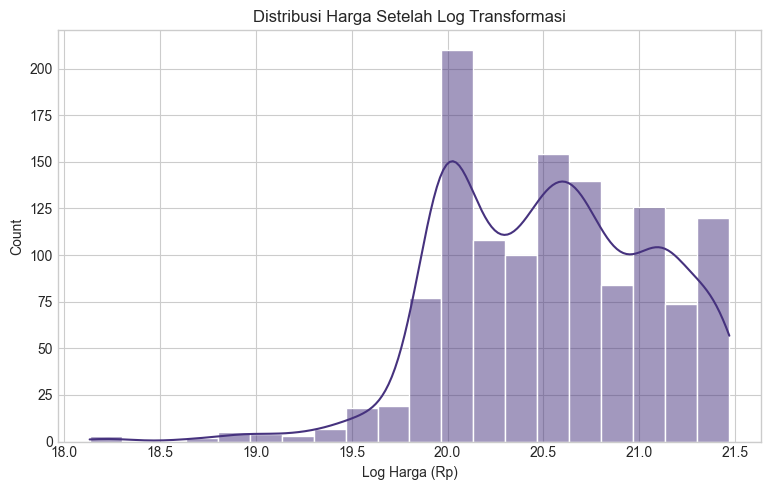


--- Statistik Distribusi Harga ---
Sebelum Transformasi:
count    2.250000e+03
mean    -4.208421e+08
std      1.582273e+09
min     -2.147484e+09
25%     -2.147484e+09
50%      4.510000e+08
75%      9.000000e+08
max      2.110000e+09
Name: price_in_rp, dtype: float64

Setelah Log Transformasi:
count    1254.000000
mean       20.535538
std         0.538333
min        18.132999
25%        20.084607
50%        20.548912
75%        20.985630
max        21.469954
Name: log_price, dtype: float64

[2] Deteksi Outlier


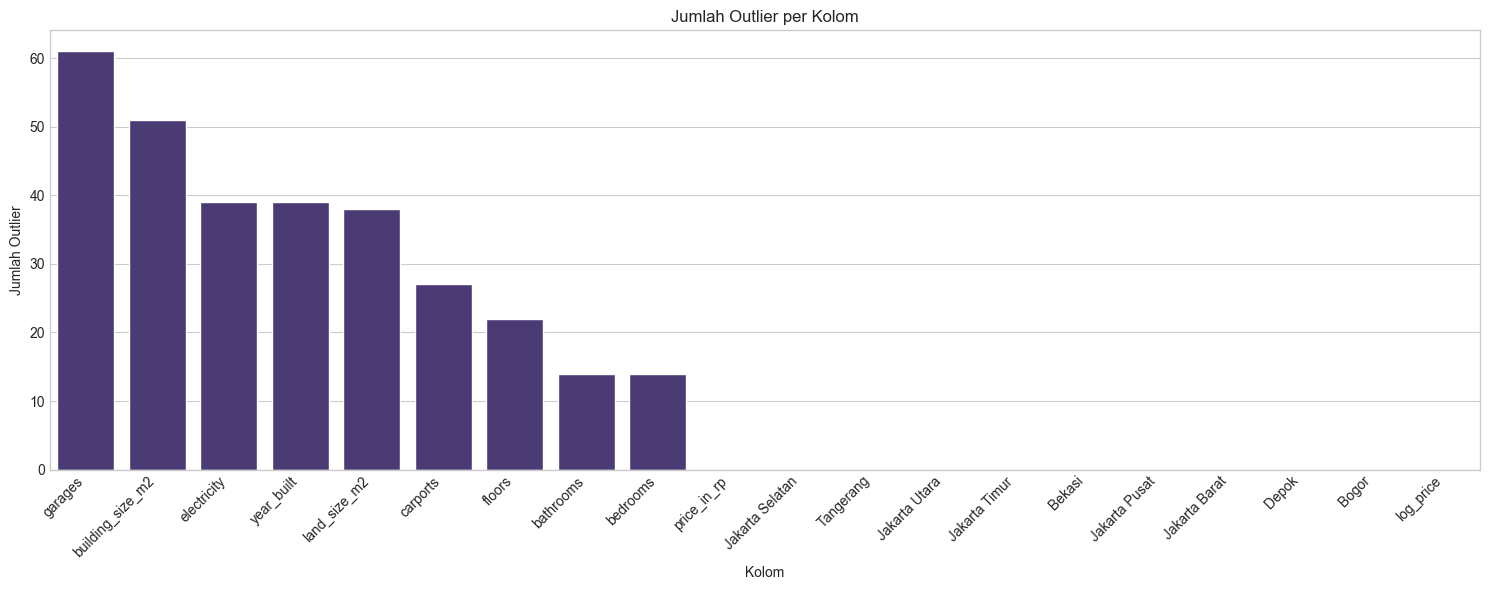


--- Detil Outlier ---
               Kolom  Jumlah Outlier
9            garages              61
4   building_size_m2              51
6        electricity              39
8         year_built              39
3       land_size_m2              38
5           carports              27
7             floors              22
2          bathrooms              14
1           bedrooms              14
0        price_in_rp               0
15   Jakarta Selatan               0
18         Tangerang               0
17     Jakarta Utara               0
16     Jakarta Timur               0
10            Bekasi               0
14     Jakarta Pusat               0
13     Jakarta Barat               0
12             Depok               0
11             Bogor               0
19         log_price               0

[3] Analisis Keseimbangan Dataset


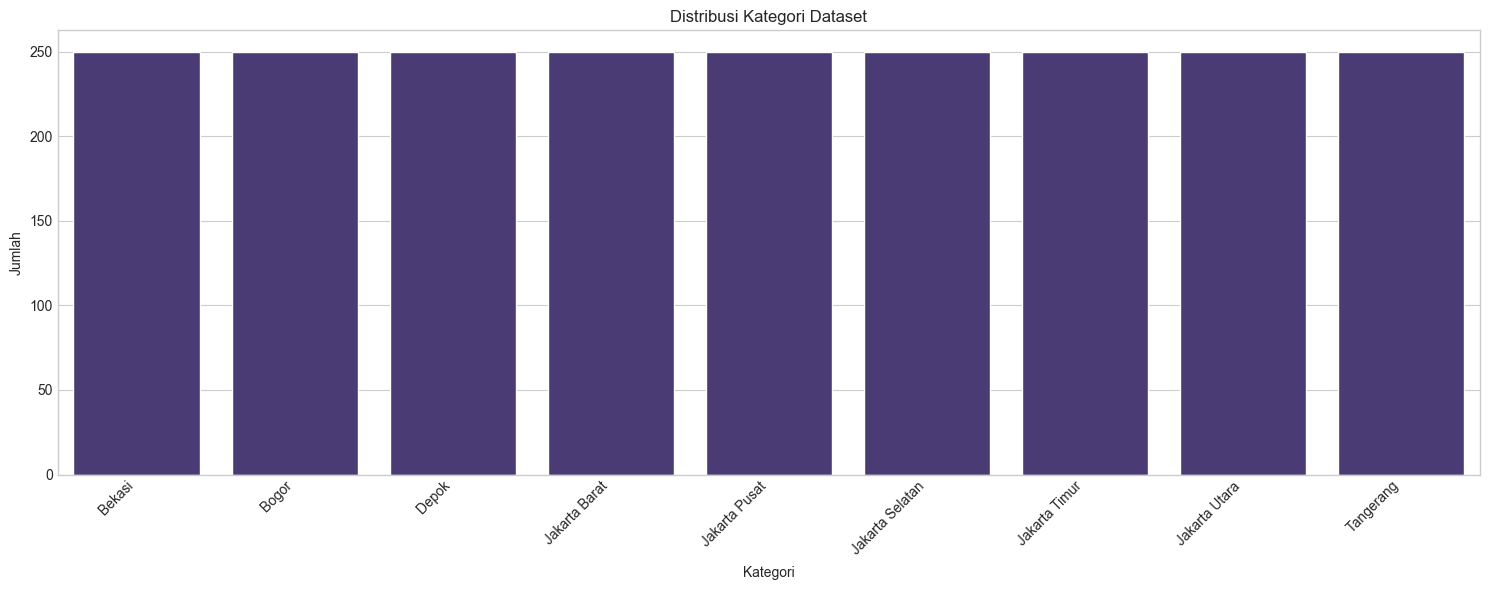


--- Distribusi Kategori ---
Bekasi             250
Bogor              250
Depok              250
Jakarta Barat      250
Jakarta Pusat      250
Jakarta Selatan    250
Jakarta Timur      250
Jakarta Utara      250
Tangerang          250
dtype: int64


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Pengaturan visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# 1. Memuat dan Memeriksa Dataset
data = pd.read_csv('balanced_dataset (2).csv')

# Fungsi untuk analisis distribusi
def analisis_distribusi_harga(data):
    plt.figure(figsize=(15, 5))

    # Distribusi setelah log transformasi
    plt.subplot(1, 2, 2)
    data['log_price'] = np.log(data['price_in_rp'])
    sns.histplot(data['log_price'], kde=True)
    plt.title('Distribusi Harga Setelah Log Transformasi')
    plt.xlabel('Log Harga (Rp)')

    plt.tight_layout()
    plt.show()

    # Statistik deskriptif
    print("\n--- Statistik Distribusi Harga ---")
    print("Sebelum Transformasi:")
    print(data['price_in_rp'].describe())
    print("\nSetelah Log Transformasi:")
    print(data['log_price'].describe())

# Fungsi untuk deteksi outlier
def deteksi_outlier(data):
    # Pilih kolom numerik
    numeric_cols = data.select_dtypes(include=[np.number]).columns

    # Hitung Z-score
    z_scores = np.abs(zscore(data[numeric_cols]))
    outliers = (z_scores > 3).sum()

    # Visualisasi outlier
    plt.figure(figsize=(15, 6))
    outliers_df = pd.DataFrame({
        'Kolom': outliers.index,
        'Jumlah Outlier': outliers.values
    }).sort_values('Jumlah Outlier', ascending=False)

    sns.barplot(x='Kolom', y='Jumlah Outlier', data=outliers_df)
    plt.title('Jumlah Outlier per Kolom')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Cetak detail outlier
    print("\n--- Detil Outlier ---")
    print(outliers_df)

# Fungsi untuk analisis keseimbangan dataset
def analisis_keseimbangan(data):
    # Identifikasi kolom one-hot encoding
    one_hot_cols = [
        col for col in data.columns
        if set(data[col].unique()).issubset({0, 1})
    ]

    # Hitung distribusi
    distribusi = data[one_hot_cols].sum().sort_values(ascending=False)

    # Visualisasi
    plt.figure(figsize=(15, 6))
    sns.barplot(x=distribusi.index, y=distribusi.values)
    plt.title('Distribusi Kategori Dataset')
    plt.xlabel('Kategori')
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Cetak distribusi
    print("\n--- Distribusi Kategori ---")
    print(distribusi)

# Jalankan analisis
def main():
    print("=== Analisis Dataset Properti ===")

    # 1. Analisis Distribusi Harga
    print("\n[1] Analisis Distribusi Harga")
    analisis_distribusi_harga(data)

    # 2. Deteksi Outlier
    print("\n[2] Deteksi Outlier")
    deteksi_outlier(data)

    # 3. Analisis Keseimbangan
    print("\n[3] Analisis Keseimbangan Dataset")
    analisis_keseimbangan(data)

# Jalankan analisis utama
main()


Categorical Features Balance Analysis:

Numerical Features Balance Analysis (after binning):

Imbalance Metrics:
  - Imbalance Ratio: 2.07
  - Maximum Proportion: 0.5013
  - Minimum Proportion: 0.2422
  - Status: Imbalanced


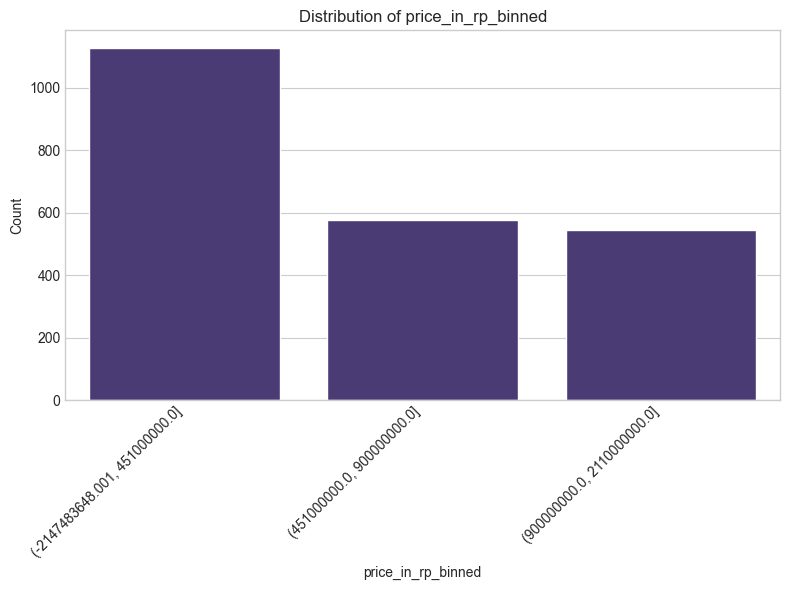


Imbalance Metrics:
  - Imbalance Ratio: 2.40
  - Maximum Proportion: 0.3227
  - Minimum Proportion: 0.1342
  - Status: Imbalanced


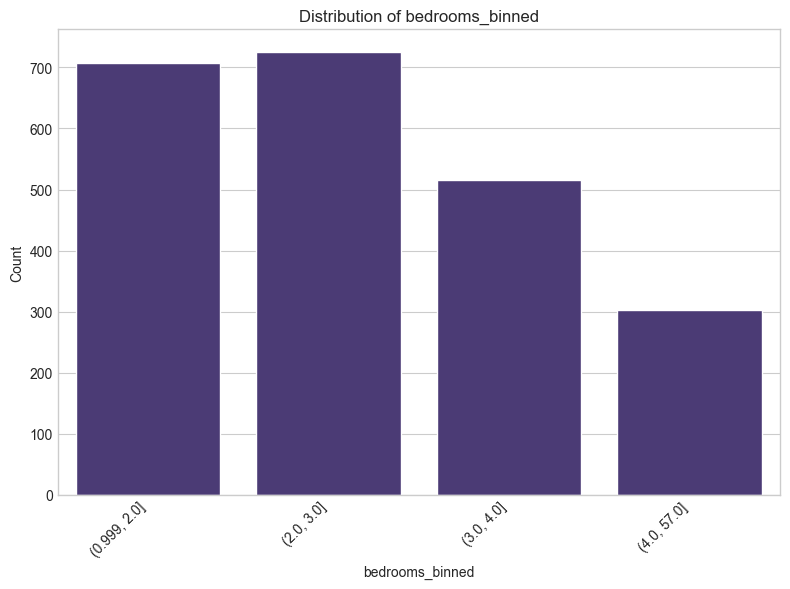


Imbalance Metrics:
  - Imbalance Ratio: 2.62
  - Maximum Proportion: 0.5227
  - Minimum Proportion: 0.1996
  - Status: Imbalanced


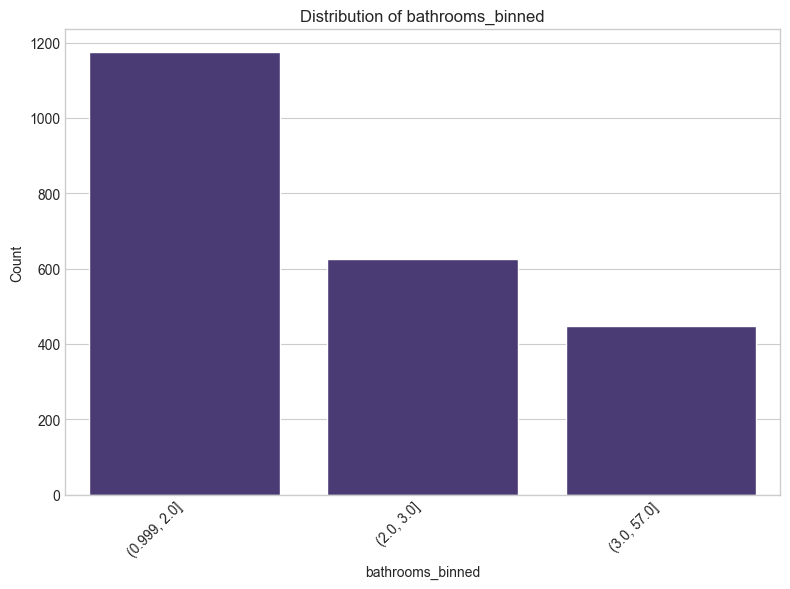


Imbalance Metrics:
  - Imbalance Ratio: 1.05
  - Maximum Proportion: 0.2578
  - Minimum Proportion: 0.2444
  - Status: Balanced


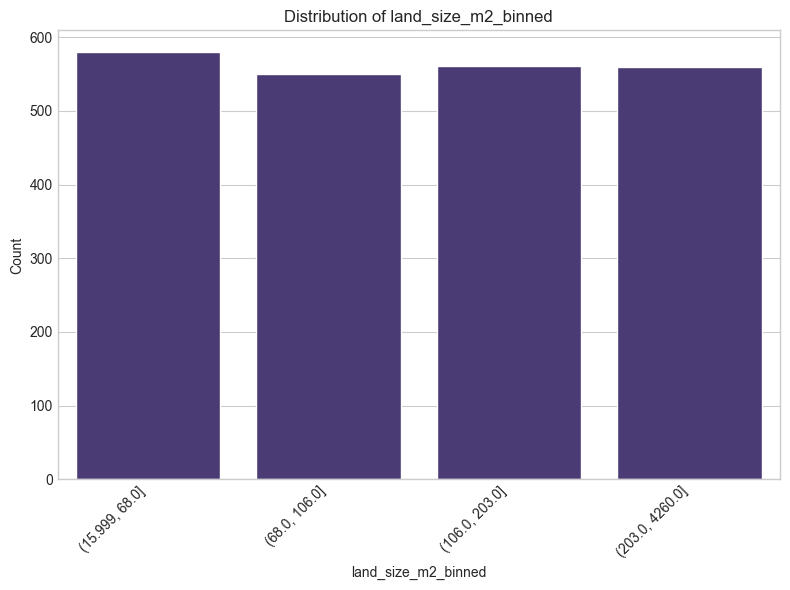


Imbalance Metrics:
  - Imbalance Ratio: 1.10
  - Maximum Proportion: 0.2618
  - Minimum Proportion: 0.2373
  - Status: Balanced


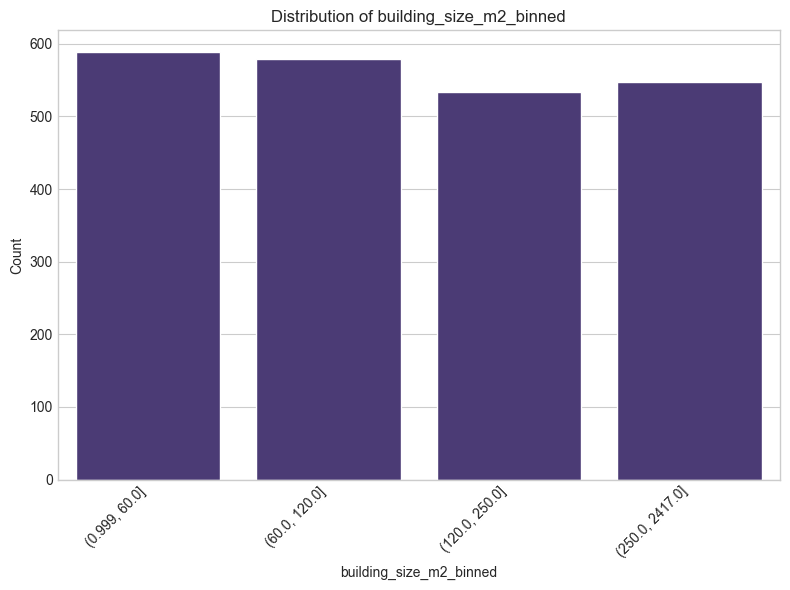


Imbalance Metrics:
  - Imbalance Ratio: 10.36
  - Maximum Proportion: 0.7089
  - Minimum Proportion: 0.0684
  - Status: Imbalanced


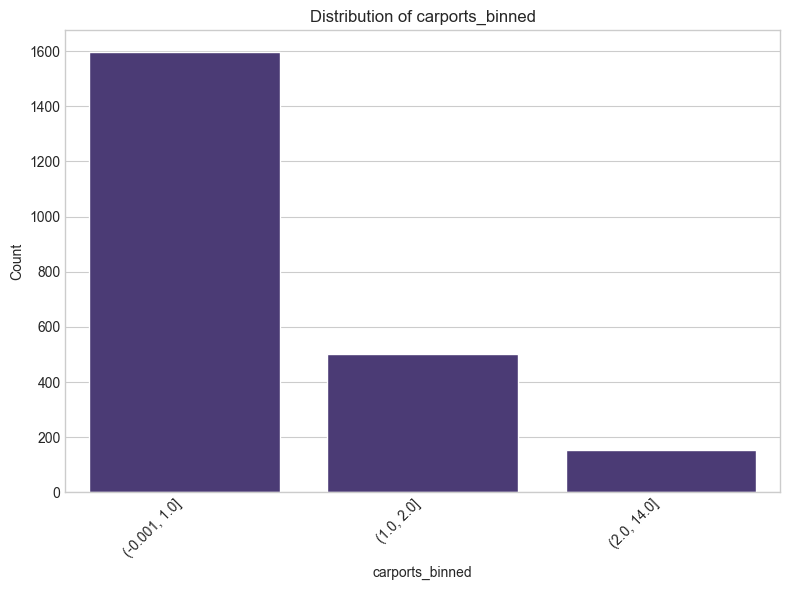


Imbalance Metrics:
  - Imbalance Ratio: 3.44
  - Maximum Proportion: 0.6049
  - Minimum Proportion: 0.1760
  - Status: Imbalanced


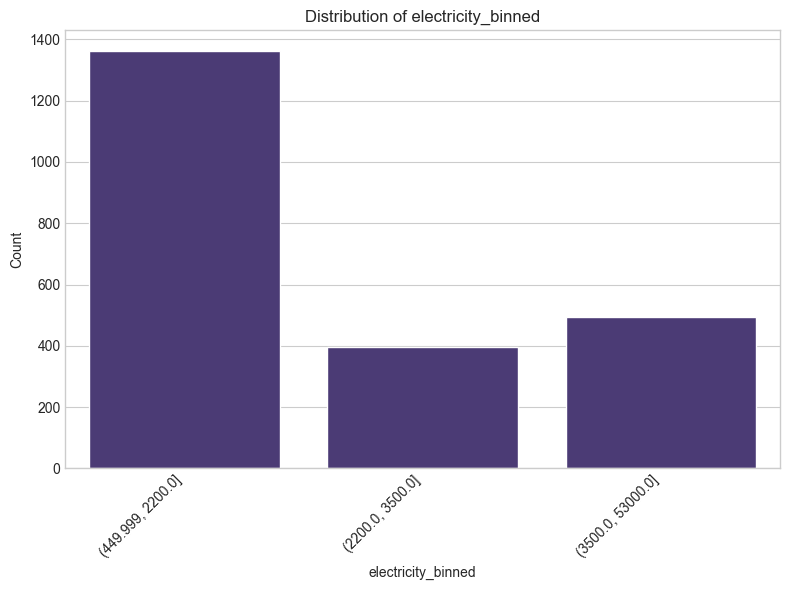


Imbalance Metrics:
  - Imbalance Ratio: 6.73
  - Maximum Proportion: 0.8707
  - Minimum Proportion: 0.1293
  - Status: Imbalanced


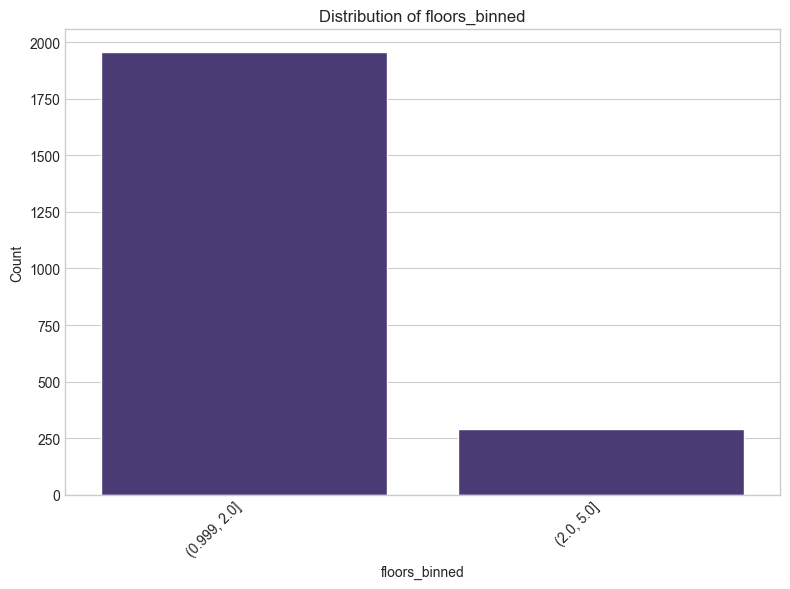


Imbalance Metrics:
  - Imbalance Ratio: 1204.00
  - Maximum Proportion: 0.5351
  - Minimum Proportion: 0.0004
  - Status: Imbalanced


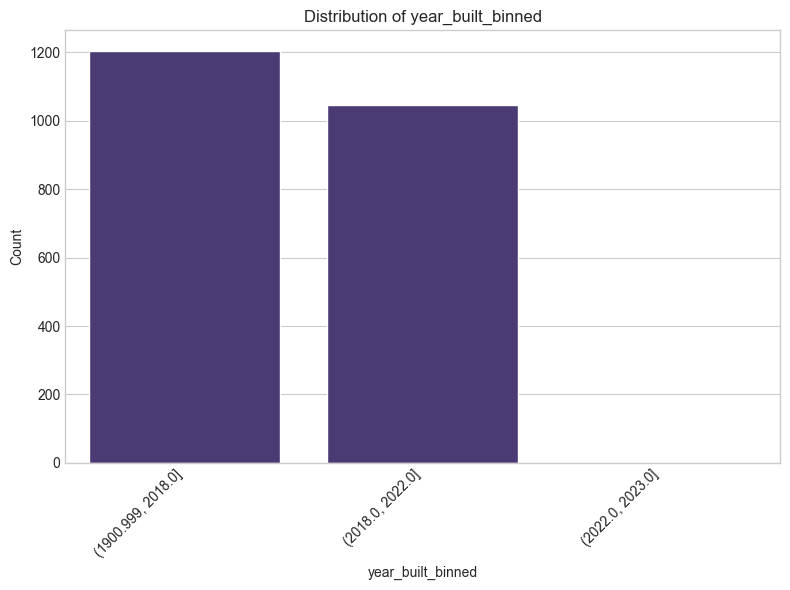


Imbalance Metrics:
  - Imbalance Ratio: 5.03
  - Maximum Proportion: 0.8342
  - Minimum Proportion: 0.1658
  - Status: Imbalanced


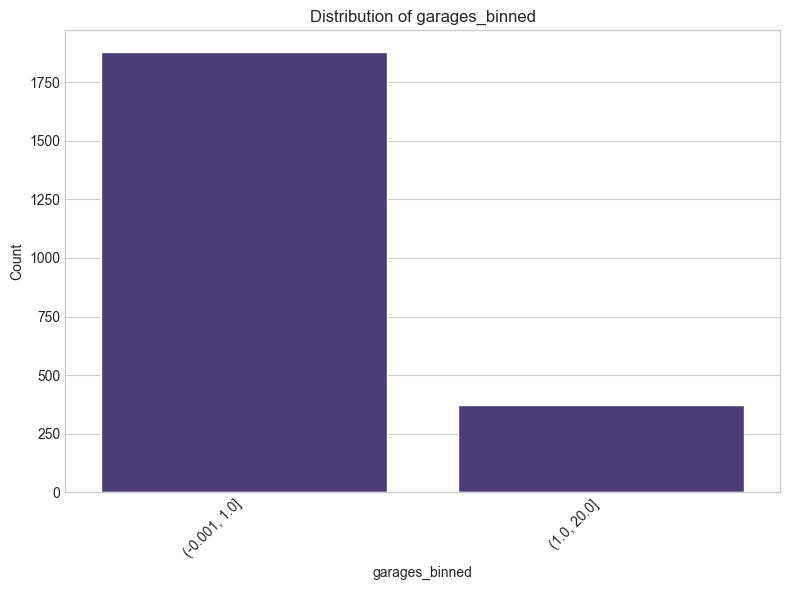


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


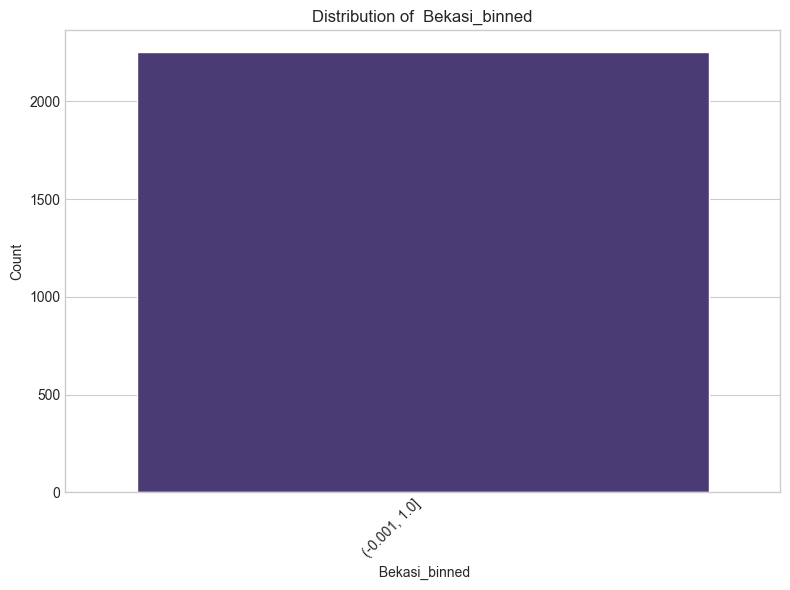


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


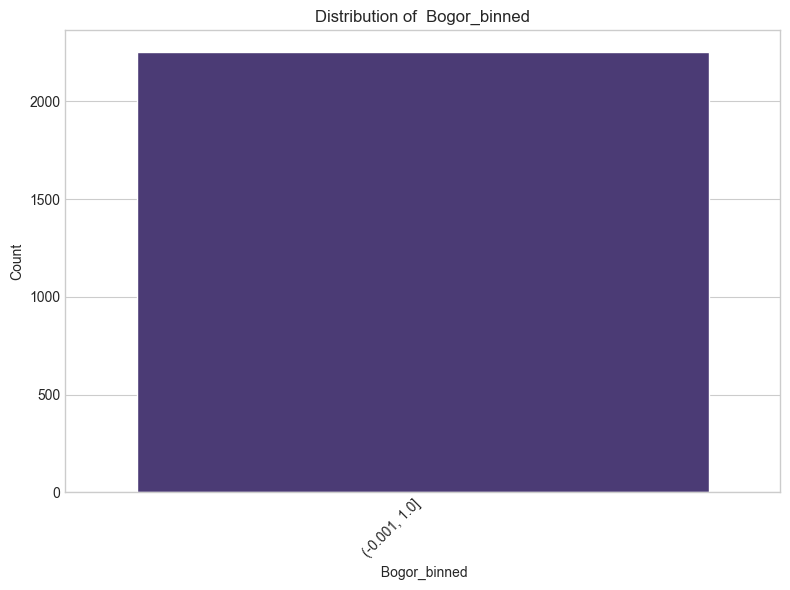


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


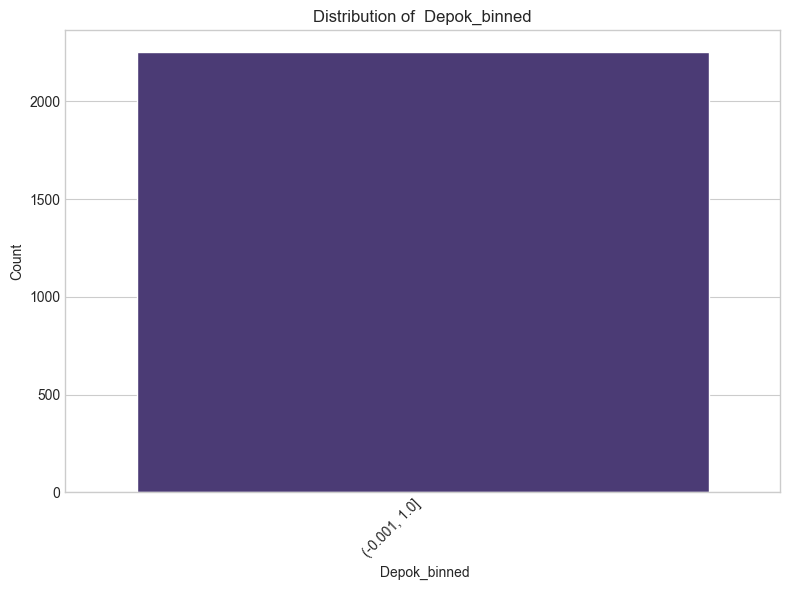


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


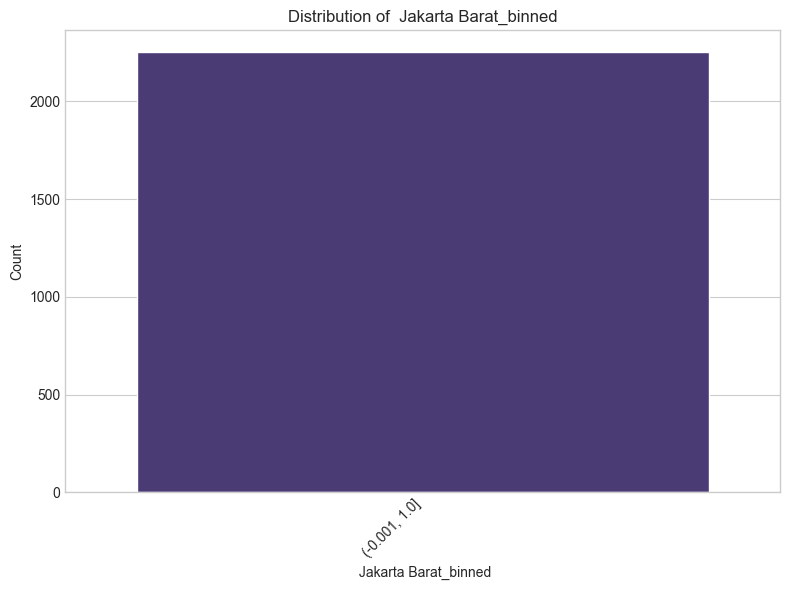


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


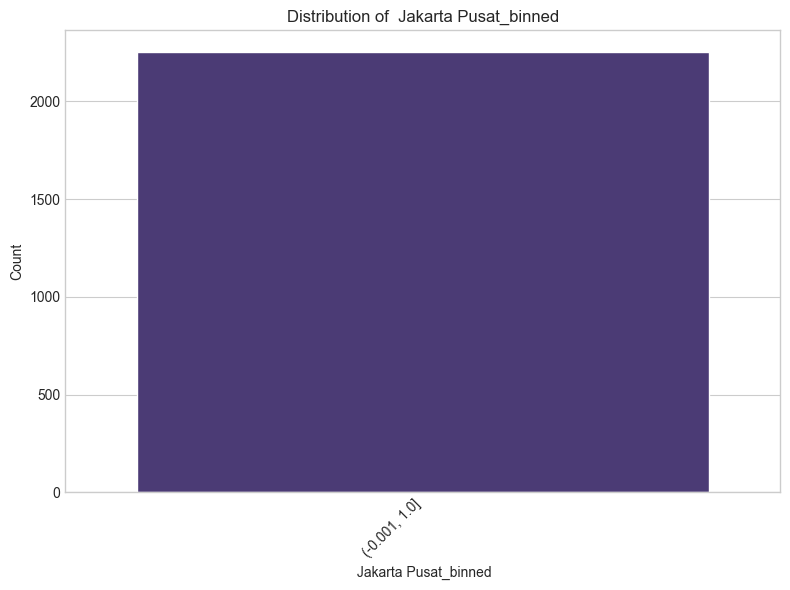


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


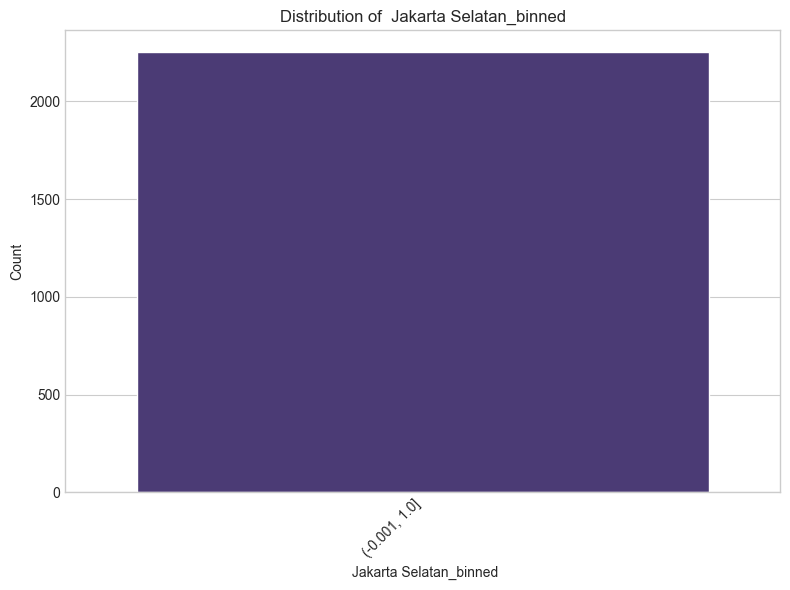


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


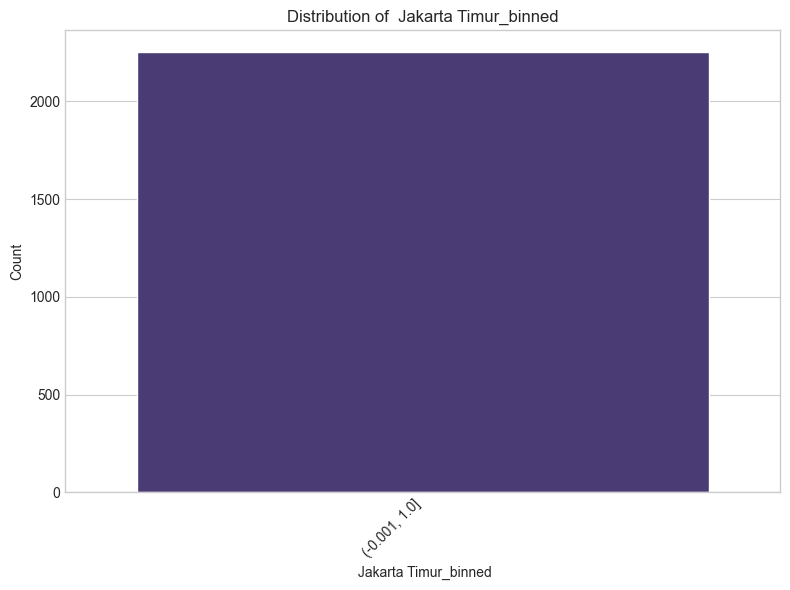


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


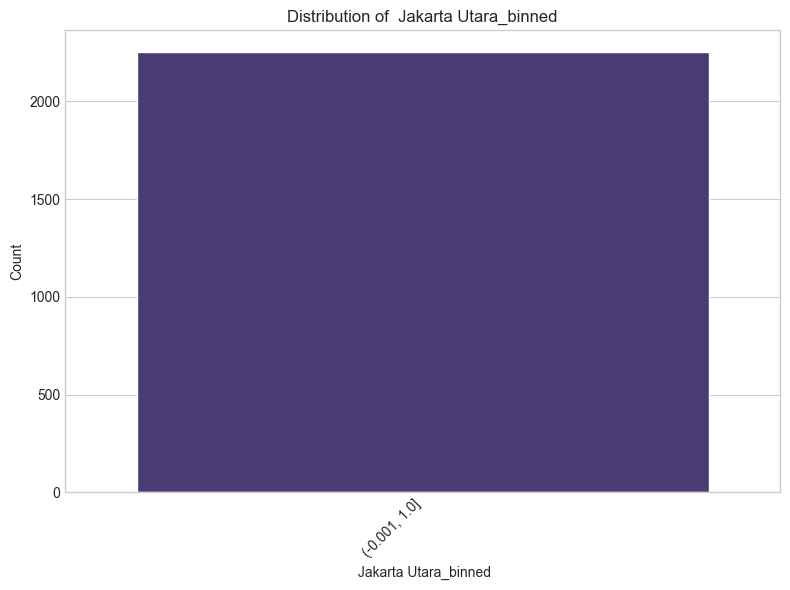


Imbalance Metrics:
  - Imbalance Ratio: 1.00
  - Maximum Proportion: 1.0000
  - Minimum Proportion: 1.0000
  - Status: Balanced


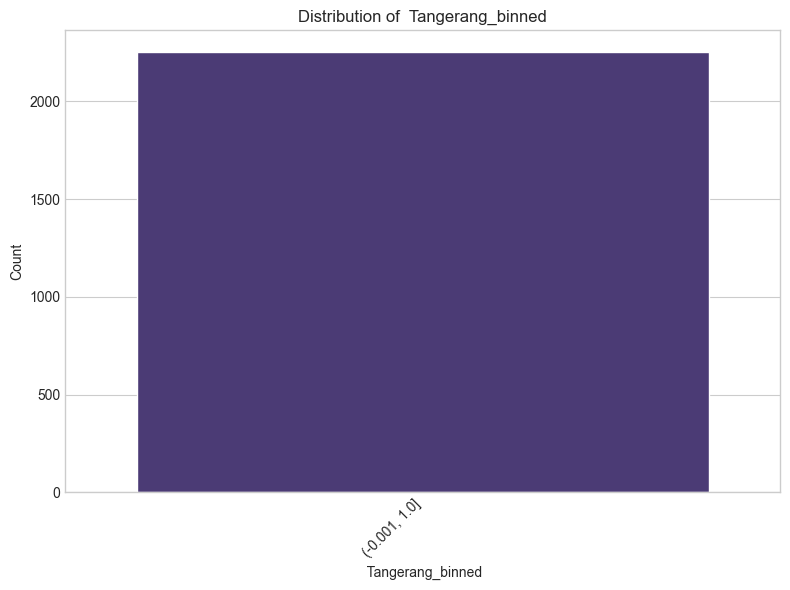


Overall Dataset Balance Summary:
Average Imbalance Ratio: 65.67

Most Imbalanced Features:

year_built_binned:
  - Imbalance Ratio: 1204.00
  - Status: Imbalanced

carports_binned:
  - Imbalance Ratio: 10.36
  - Status: Imbalanced

floors_binned:
  - Imbalance Ratio: 6.73
  - Status: Imbalanced


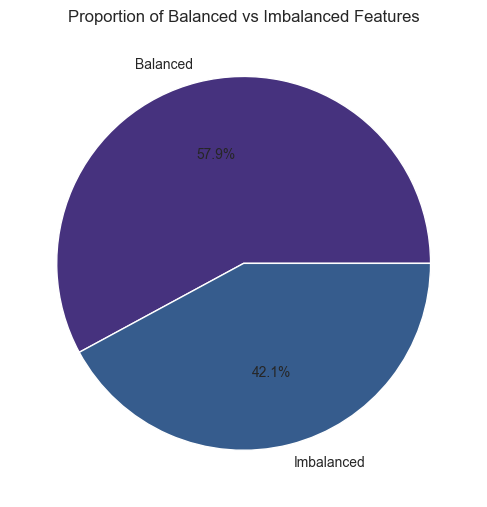

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_balance(data, column, threshold=0.2):
    """
    Analyze balance/imbalance in a column.
    threshold: maximum ratio difference to consider as balanced
    """
    value_counts = data[column].value_counts()
    proportions = value_counts / len(data)

    max_prop = proportions.max()
    min_prop = proportions.min()
    imbalance_ratio = max_prop / min_prop if min_prop > 0 else float('inf')

    print(f"\nImbalance Metrics:")
    print(f"  - Imbalance Ratio: {imbalance_ratio:.2f}")
    print(f"  - Maximum Proportion: {max_prop:.4f}")
    print(f"  - Minimum Proportion: {min_prop:.4f}")

    status = "Imbalanced" if imbalance_ratio > (1 + threshold) else "Balanced"
    print(f"  - Status: {status}")

    return {
        'column': column,
        'status': status,
        'imbalance_ratio': imbalance_ratio,
        'distribution': value_counts
    }

def plot_balance_distribution(data, column):
    """Plot the distribution of a categorical feature."""
    plt.figure(figsize=(8, 6))
    sns.countplot(data=data, x=column)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_balance_dashboard(imbalance_df, balance_results):
    """Plot a dashboard of balance analysis for all features."""
    fig = plt.figure(figsize=(15, 10))
    gs = plt.GridSpec(2, 2, figure=fig)

    ax2 = fig.add_subplot(gs[1, 0])
    balance_status = pd.Series([r['status'] for r in balance_results.values()]).value_counts()
    ax2.pie(balance_status, labels=balance_status.index, autopct='%1.1f%%')
    ax2.set_title('Proportion of Balanced vs Imbalanced Features')
    plt.tight_layout()
    plt.show()

def analyze_dataset_balance(data):
    """Perform balance analysis for both categorical and binned numerical features."""
    categorical_cols = data.select_dtypes(include=['object']).columns
    balance_results = {}

    print("\nCategorical Features Balance Analysis:")
    for col in categorical_cols:
        balance_results[col] = analyze_balance(data, col)
        plot_balance_distribution(data, col)

    numeric_cols = data.select_dtypes(include=['number']).columns
    print("\nNumerical Features Balance Analysis (after binning):")
    for col in numeric_cols:
        data[f'{col}_binned'] = pd.qcut(data[col], q=4, duplicates='drop')
        balance_results[f'{col}_binned'] = analyze_balance(data, f'{col}_binned')
        plot_balance_distribution(data, f'{col}_binned')
        data = data.drop(columns=[f'{col}_binned'])

    imbalance_scores = [result['imbalance_ratio'] for result in balance_results.values()]
    overall_imbalance = np.mean(imbalance_scores)

    print("\nOverall Dataset Balance Summary:")
    print(f"Average Imbalance Ratio: {overall_imbalance:.2f}")

    sorted_imbalance = sorted(balance_results.items(),
                            key=lambda x: x[1]['imbalance_ratio'],
                            reverse=True)

    print("\nMost Imbalanced Features:")
    for feature, result in sorted_imbalance[:3]:
        print(f"\n{feature}:")
        print(f"  - Imbalance Ratio: {result['imbalance_ratio']:.2f}")
        print(f"  - Status: {result['status']}")

    imbalance_df = pd.DataFrame([
        {'Feature': k, 'Imbalance_Ratio': v['imbalance_ratio']}
        for k, v in balance_results.items()
    ])

    plot_balance_dashboard(imbalance_df, balance_results)

if __name__ == "__main__":
    # Example usage
    # Load dataset (adjust path as needed)
    file_path = 'balanced_dataset.csv'
    data = pd.read_csv(file_path)

    # Perform the balance analysis
    analyze_dataset_balance(data)

